# Paradigma 2: VLM Prompting (Zero-Shot)

Acest notebook evaluează un Vision-Language Model pe aceleași date
pentru a compara cu pipeline-ul clasic (Paradigma 1).

- Qwen2.5-VL-3B (open-source)



In [ ]:
# 1. Upload dataset
# Upload: test.csv + attachments/ folder (as zip)
from google.colab import files
import os, zipfile

print('Upload test.csv:')
uploaded = files.upload()

print('\nUpload attachments.zip:')
uploaded2 = files.upload()

# Extract attachments
if 'attachments.zip' in uploaded2:
    with zipfile.ZipFile('attachments.zip', 'r') as z:
        z.extractall('.')
    print(f'Extracted {len(os.listdir("attachments"))} files')
else:
    print('WARNING: attachments.zip not found, upload manually')

Upload test.csv:


Saving test.csv to test.csv

Upload attachments.zip:


Saving attachments_test.zip to attachments_test.zip


In [ ]:
import zipfile
with zipfile.ZipFile('attachments_test.zip', 'r') as z:
    z.extractall('.')
    print(f"Extracted {len(z.namelist())} files")

import os
print(f"attachments/ exists: {os.path.exists('attachments')}")
print(f"Files: {os.listdir('attachments')[:5]}")

Extracted 55 files
attachments/ exists: True
Files: ['quotation_0104.png', 'quotation_0079.pdf', 'quotation_0090.png', 'invoice_0195.pdf', 'invoice_0135.png']


In [ ]:
!pip install -q transformers accelerate qwen-vl-utils pypdfium2
!pip install -q anthropic scikit-learn pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 478.8/478.8 kB 13.3 MB/s eta 0:00:00


In [ ]:
import zipfile
with zipfile.ZipFile('attachments_test.zip', 'r') as z:
    z.extractall('.')
    print(f"Extracted {len(z.namelist())} files")

import os
print(f"attachments/ exists: {os.path.exists('attachments')}")
print(f"Files: {os.listdir('attachments')[:5]}")

Extracted 55 files
attachments/ exists: True
Files: ['quotation_0104.png', 'quotation_0079.pdf', 'quotation_0090.png', 'invoice_0195.pdf', 'invoice_0135.png']


In [ ]:
# 3. Configuration & data loading
import csv
import json
import re
import os
import base64
from datetime import datetime
from PIL import Image
from collections import Counter

INTENT_LABELS = [
    'invoice_submission', 'other', 'price_increase',
    'price_validity_confirmation', 'quote_offer',
]
def load_test_data(path='test.csv'):
    records = []
    with open(path, 'r', encoding='utf-8-sig') as f:
        for row in csv.DictReader(f):
            records.append(row)
    return records

records = load_test_data()
records_with_attach = [r for r in records if r.get('attachment_path', '')]
print(f'Total: {len(records)}, With attachments: {len(records_with_attach)}')

Total: 86, With attachments: 55


In [ ]:
# 4. Define the prompt template


SYSTEM_PROMPT = """You are a document analysis system. You will receive an email from a supplier
and optionally a document image (invoice, quotation, or price list).

Your task is to extract structured information and detect any mismatches.

Respond ONLY with a JSON object (no markdown, no backticks, no explanation). The JSON must have:
{
  "intent": one of ["invoice_submission", "quote_offer", "price_increase", "price_validity_confirmation", "other"],
  "email_fields": {
    "amount": number or null,
    "currency": "USD"/"EUR"/"GBP"/"RON"/"CHF" or null,
    "doc_number": string or null,
    "date": "YYYY-MM-DD" or null
  },
  "document_fields": {
    "amount": number or null,
    "currency": "USD"/"EUR"/"GBP"/"RON"/"CHF" or null,
    "doc_number": string or null,
    "date": "YYYY-MM-DD" or null
  },
  "is_consistent": true/false,
  "mismatched_fields": [list of field names that differ between email and document]
}

Rules:
- For "date": extract the due date (invoices), validity end date (quotations), or effective date (price changes)
- For "amount": extract the TOTAL amount, not line items
- Set fields to null if not found in that source
- "is_consistent" should be false only if the SAME field has DIFFERENT values in email vs document
- If a field is null in one source, it cannot be a mismatch
"""

def build_user_prompt(email_subject, email_body, has_image=False):
    prompt = f"""Email subject: {email_subject}

Email body:
{email_body}
"""
    if has_image:
        prompt += "\nThe attached document image is provided. Extract fields from both the email and the document."
    else:
        prompt += "\nNo document is attached. Extract fields from the email only. Set all document_fields to null."
    return prompt

print('Prompts defined.')

Prompts defined.


---
Qwen2.5-VL (Open-Source, pe Colab)
Model: Qwen/Qwen2.5-VL-3B-Instruct

In [ ]:
# Load Qwen2.5-VL model
import torch
from transformers import AutoModelForImageTextToText, AutoProcessor

MODEL_ID = 'Qwen/Qwen2.5-VL-3B-Instruct'

print(f'Loading {MODEL_ID}...')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map='auto',
    attn_implementation='eager',
)
processor = AutoProcessor.from_pretrained(MODEL_ID)
print('Model loaded!')

Loading Qwen/Qwen2.5-VL-3B-Instruct...
GPU: Tesla T4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


`torch_dtype` is deprecated! Use `dtype` instead!


The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Model loaded!


In [ ]:
# Inference function for Qwen2.5-VL
import pypdfium2 as pdfium

def load_image(path):
    """Load document as PIL Image (PDF or PNG)."""
    if path.lower().endswith('.pdf'):
        pdf = pdfium.PdfDocument(path)
        page = pdf[0]
        bitmap = page.render(scale=200/72)
        img = bitmap.to_pil()
        pdf.close()
        return img
    return Image.open(path).convert('RGB')


def query_qwen(email_subject, email_body, image_path=None, max_tokens=600):
    """Send a query to Qwen2.5-VL and get structured JSON response."""
    user_prompt = build_user_prompt(email_subject, email_body, image_path is not None)

    # Build messages
    content = []
    if image_path and os.path.exists(image_path):
        img = load_image(image_path)
        # Resize if too large for memory
        max_dim = 1024
        if max(img.size) > max_dim:
            ratio = max_dim / max(img.size)
            img = img.resize((int(img.width * ratio), int(img.height * ratio)))
        content.append({'type': 'image', 'image': img})
    content.append({'type': 'text', 'text': user_prompt})

    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': content},
    ]

    # Process
    text_input = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    if image_path and os.path.exists(image_path):
        inputs = processor(
            text=[text_input],
            images=[img],
            padding=True,
            return_tensors='pt',
        ).to(model.device)
    else:
        inputs = processor(
            text=[text_input],
            padding=True,
            return_tensors='pt',
        ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            temperature=0.0,
        )

    # Decode only the generated part
    gen_ids = output_ids[:, inputs['input_ids'].shape[1]:]
    response = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
    return response

print('Inference function ready.')

Inference function ready.


In [ ]:
# 7. Choose which function to use

query_fn = query_qwen

print(f'Using: {query_fn.__name__}')

Using: query_qwen


In [ ]:
# 8. Parse VLM response

def parse_vlm_response(response_text):
    """Parse JSON from VLM response, handling common issues."""
    # Clean up common issues
    text = response_text.strip()
    # Remove markdown code fences
    text = re.sub(r'^```(?:json)?\s*', '', text)
    text = re.sub(r'\s*```$', '', text)
    text = text.strip()

    try:
        result = json.loads(text)
        return result
    except json.JSONDecodeError:
        # Try to find JSON object in the response
        match = re.search(r'\{[^{}]*(?:\{[^{}]*\}[^{}]*)*\}', text, re.DOTALL)
        if match:
            try:
                return json.loads(match.group())
            except json.JSONDecodeError:
                pass
    return None


def normalize_date_vlm(date_str):
    """Normalize date from VLM output."""
    if not date_str:
        return None
    date_str = str(date_str).strip()
    # Already YYYY-MM-DD
    if re.match(r'^\d{4}-\d{2}-\d{2}$', date_str):
        return date_str
    # Try common formats
    for fmt in ['%B %d, %Y', '%B %d %Y', '%d %b %Y', '%m/%d/%Y', '%d/%m/%Y']:
        try:
            return datetime.strptime(date_str.replace(',',''), fmt).strftime('%Y-%m-%d')
        except ValueError:
            continue
    return date_str

print('Parser ready.')

Parser ready.


In [ ]:
# 9. Run evaluation on ALL test records
import time

vlm_results = []
parse_failures = 0

print(f'Processing {len(records)} records...')
start_time = time.time()

for i, rec in enumerate(records):
    email_subject = rec.get('subject', '')
    email_body = rec.get('body', '')
    attach_path = rec.get('attachment_path', '')

    image_path = attach_path if attach_path and os.path.exists(attach_path) else None

    try:
        raw_response = query_fn(email_subject, email_body, image_path)
        parsed = parse_vlm_response(raw_response)

        if parsed is None:
            parse_failures += 1
            parsed = {
                'intent': 'other',
                'email_fields': {'amount': None, 'currency': None, 'doc_number': None, 'date': None},
                'document_fields': {'amount': None, 'currency': None, 'doc_number': None, 'date': None},
                'is_consistent': True,
                'mismatched_fields': [],
            }

        vlm_results.append({
            'email_id': rec['email_id'],
            'parsed': parsed,
            'raw_response': raw_response[:500],
        })

    except Exception as e:
        parse_failures += 1
        vlm_results.append({
            'email_id': rec['email_id'],
            'parsed': None,
            'error': str(e),
        })

    if (i + 1) % 10 == 0:
        elapsed = time.time() - start_time
        eta = elapsed / (i + 1) * (len(records) - i - 1)
        print(f'  [{i+1}/{len(records)}] done  |  '
              f'Parse failures: {parse_failures}  |  '
              f'ETA: {eta/60:.1f} min')

elapsed = time.time() - start_time
print(f'\nDone! {len(records)} records in {elapsed/60:.1f} min')
print(f'Parse failures: {parse_failures}')

Processing 86 records...


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  [10/86] done  |  Parse failures: 0  |  ETA: 11.5 min
  [20/86] done  |  Parse failures: 0  |  ETA: 9.8 min
  [30/86] done  |  Parse failures: 0  |  ETA: 8.4 min
  [40/86] done  |  Parse failures: 0  |  ETA: 6.7 min
  [50/86] done  |  Parse failures: 0  |  ETA: 5.3 min
  [60/86] done  |  Parse failures: 0  |  ETA: 3.9 min
  [70/86] done  |  Parse failures: 0  |  ETA: 2.4 min
  [80/86] done  |  Parse failures: 0  |  ETA: 0.9 min

Done! 86 records in 12.8 min
Parse failures: 0


In [ ]:
# 10. Evaluate VLM results
from sklearn.metrics import classification_report, accuracy_score, f1_score

# === INTENT CLASSIFICATION ===
true_intents = []
pred_intents = []
for rec, vlm in zip(records, vlm_results):
    true_intents.append(rec['intent'])
    parsed = vlm.get('parsed') or {}
    pred = parsed.get('intent', 'other')
    if pred not in INTENT_LABELS:
        pred = 'other'
    pred_intents.append(pred)

intent_acc = accuracy_score(true_intents, pred_intents)
intent_f1 = f1_score(true_intents, pred_intents, average='macro', zero_division=0)

print('=== VLM: INTENT CLASSIFICATION ===')
print(classification_report(true_intents, pred_intents,
                            labels=INTENT_LABELS, digits=4, zero_division=0))
print(f'Accuracy: {intent_acc:.4f}  |  F1 macro: {intent_f1:.4f}')

=== VLM: INTENT CLASSIFICATION ===
                             precision    recall  f1-score   support

         invoice_submission     1.0000    1.0000    1.0000        20
                      other     1.0000    0.8235    0.9032        17
             price_increase     0.8824    1.0000    0.9375        15
price_validity_confirmation     1.0000    0.2857    0.4444        14
                quote_offer     0.6452    1.0000    0.7843        20

                   accuracy                         0.8488        86
                  macro avg     0.9055    0.8218    0.8139        86
               weighted avg     0.8970    0.8488    0.8294        86

Accuracy: 0.8488  |  F1 macro: 0.8139


In [ ]:
# === EMAIL FIELD EXTRACTION ===

def fields_match_vlm(pred_val, gt_val, field_type):
    if pred_val is None or gt_val is None or gt_val == '':
        return None  # Can't evaluate
    if field_type == 'amount':
        try:
            p, g = float(pred_val), float(gt_val)
            return abs(p - g) < max(1.0, g * 0.01)
        except (ValueError, TypeError):
            return False
    elif field_type == 'currency':
        return str(pred_val).upper() == str(gt_val).upper()
    elif field_type == 'doc_number':
        return re.sub(r'[-/\s]', '', str(pred_val).upper()) == \
               re.sub(r'[-/\s]', '', str(gt_val).upper())
    elif field_type == 'date':
        norm_pred = normalize_date_vlm(pred_val)
        return norm_pred == str(gt_val)
    return str(pred_val) == str(gt_val)

# Email fields
email_field_stats = {f: {'correct': 0, 'incorrect': 0, 'total': 0}
                     for f in ['amount', 'currency', 'doc_number', 'date']}

for rec, vlm in zip(records, vlm_results):
    parsed = vlm.get('parsed') or {}
    email_fields = parsed.get('email_fields', {})

    for field in ['amount', 'currency', 'doc_number', 'date']:
        gt = rec.get(f'gt_{field}', '')
        mentions = rec.get(f'mentions_{field}', 'False') == 'True'
        if not mentions or not gt:
            continue

        pred = email_fields.get(field)
        email_field_stats[field]['total'] += 1

        match = fields_match_vlm(pred, gt, field)
        if match:
            email_field_stats[field]['correct'] += 1
        else:
            email_field_stats[field]['incorrect'] += 1

print('\n=== VLM: EMAIL FIELD EXTRACTION ===')
print(f'{"Field":<15s} {"Correct":>8s} {"Wrong":>8s} {"Total":>8s} {"Accuracy":>10s}')
print('-' * 55)
total_c, total_t = 0, 0
for field in ['amount', 'currency', 'doc_number', 'date']:
    s = email_field_stats[field]
    acc = s['correct'] / s['total'] if s['total'] > 0 else 0
    print(f'{field:<15s} {s["correct"]:>8d} {s["incorrect"]:>8d} {s["total"]:>8d} {acc:>10.2%}')
    total_c += s['correct']
    total_t += s['total']
print(f'{"OVERALL":<15s} {total_c:>8d} {total_t-total_c:>8d} {total_t:>8d} {total_c/total_t if total_t else 0:>10.2%}')


=== VLM: EMAIL FIELD EXTRACTION ===
Field            Correct    Wrong    Total   Accuracy
-------------------------------------------------------
amount                27        2       29     93.10%
currency              29        0       29    100.00%
doc_number            24        0       24    100.00%
date                  19       10       29     65.52%
OVERALL               99       12      111     89.19%


In [ ]:
# === DOCUMENT FIELD EXTRACTION ===

doc_field_stats = {f: {'correct': 0, 'incorrect': 0, 'total': 0}
                   for f in ['amount', 'currency', 'doc_number', 'date']}

for rec, vlm in zip(records, vlm_results):
    if not rec.get('attachment_path', ''):
        continue
    parsed = vlm.get('parsed') or {}
    doc_fields = parsed.get('document_fields', {})

    for field in ['amount', 'currency', 'doc_number', 'date']:
        gt = rec.get(f'doc_{field}', '')
        if not gt:
            continue

        pred = doc_fields.get(field)
        doc_field_stats[field]['total'] += 1

        match = fields_match_vlm(pred, gt, field)
        if match:
            doc_field_stats[field]['correct'] += 1
        else:
            doc_field_stats[field]['incorrect'] += 1

print('\n=== VLM: DOCUMENT FIELD EXTRACTION ===')
print(f'{"Field":<15s} {"Correct":>8s} {"Wrong":>8s} {"Total":>8s} {"Accuracy":>10s}')
print('-' * 55)
total_c, total_t = 0, 0
for field in ['amount', 'currency', 'doc_number', 'date']:
    s = doc_field_stats[field]
    acc = s['correct'] / s['total'] if s['total'] > 0 else 0
    print(f'{field:<15s} {s["correct"]:>8d} {s["incorrect"]:>8d} {s["total"]:>8d} {acc:>10.2%}')
    total_c += s['correct']
    total_t += s['total']
print(f'{"OVERALL":<15s} {total_c:>8d} {total_t-total_c:>8d} {total_t:>8d} {total_c/total_t if total_t else 0:>10.2%}')


=== VLM: DOCUMENT FIELD EXTRACTION ===
Field            Correct    Wrong    Total   Accuracy
-------------------------------------------------------
amount                54        1       55     98.18%
currency              55        0       55    100.00%
doc_number            44       11       55     80.00%
date                   6       49       55     10.91%
OVERALL              159       61      220     72.27%


In [ ]:
# === MISMATCH DETECTION ===

tp, fp, tn, fn = 0, 0, 0, 0

for rec, vlm in zip(records, vlm_results):
    if not rec.get('attachment_path', ''):
        continue

    gt_consistent = rec.get('is_consistent', 'True') == 'True'
    parsed = vlm.get('parsed') or {}
    pred_consistent = parsed.get('is_consistent', True)
    # Handle string 'true'/'false'
    if isinstance(pred_consistent, str):
        pred_consistent = pred_consistent.lower() == 'true'

    if gt_consistent and pred_consistent:
        tn += 1
    elif gt_consistent and not pred_consistent:
        fp += 1
    elif not gt_consistent and not pred_consistent:
        tp += 1
    else:
        fn += 1

total = tp + fp + tn + fn
mm_acc = (tp + tn) / total if total > 0 else 0
mm_prec = tp / (tp + fp) if (tp + fp) > 0 else 0
mm_rec = tp / (tp + fn) if (tp + fn) > 0 else 0
mm_f1 = 2 * mm_prec * mm_rec / (mm_prec + mm_rec) if (mm_prec + mm_rec) > 0 else 0

print('\n=== VLM: MISMATCH DETECTION ===')
print(f'Confusion Matrix:')
print(f'  {"":>20s} {"Pred Consistent":>18s} {"Pred Mismatch":>15s}')
print(f'  {"GT Consistent":>20s} {tn:>18d} {fp:>15d}')
print(f'  {"GT Mismatch":>20s} {fn:>18d} {tp:>15d}')
print(f'\n  Accuracy:   {mm_acc:.4f}')
print(f'  Precision:  {mm_prec:.4f}')
print(f'  Recall:     {mm_rec:.4f}')
print(f'  F1 Score:   {mm_f1:.4f}')


=== VLM: MISMATCH DETECTION ===
Confusion Matrix:
                          Pred Consistent   Pred Mismatch
         GT Consistent                 28              15
           GT Mismatch                  1              11

  Accuracy:   0.7091
  Precision:  0.4231
  Recall:     0.9167
  F1 Score:   0.5789


In [ ]:
# 11. FINAL COMPARISON TABLE
# Rhe Paradigm 1 results from your reconciliation.py output

# ──── Paradigm 1 results ────
P1_INTENT_ACC = 1.0000
P1_INTENT_F1 = 1.0000
P1_EMAIL_FIELD_ACC = 1.0000
P1_DOC_FIELD_ACC = 0.9773
P1_MISMATCH_ACC = 0.9818
P1_MISMATCH_PREC = 1.0000
P1_MISMATCH_REC = 0.9167
P1_MISMATCH_F1 = 0.9565
# ────────────────────────────────────────────────────────

# VLM results
vlm_email_acc = total_c / total_t if total_t > 0 else 0  # from email field cell
vlm_doc_acc_c = sum(doc_field_stats[f]['correct'] for f in doc_field_stats)
vlm_doc_acc_t = sum(doc_field_stats[f]['total'] for f in doc_field_stats)
vlm_doc_acc = vlm_doc_acc_c / vlm_doc_acc_t if vlm_doc_acc_t > 0 else 0

print('=' * 75)
print('PARADIGM COMPARISON — DISSERTATION RESULTS')
print('=' * 75)
print(f'{"Metric":<35s} {"Pipeline (P1)":>15s} {"VLM Zero-Shot (P2)":>20s}')
print('-' * 75)
print(f'{"Intent Classification Accuracy":<35s} {P1_INTENT_ACC:>15.2%} {intent_acc:>20.2%}')
print(f'{"Intent Classification F1 (macro)":<35s} {P1_INTENT_F1:>15.2%} {intent_f1:>20.2%}')
print(f'{"Email Field Extraction Accuracy":<35s} {P1_EMAIL_FIELD_ACC:>15.2%} {vlm_email_acc:>20.2%}')
print(f'{"Document Field Extraction Accuracy":<35s} {P1_DOC_FIELD_ACC:>15.2%} {vlm_doc_acc:>20.2%}')
print(f'{"Mismatch Detection Accuracy":<35s} {P1_MISMATCH_ACC:>15.2%} {mm_acc:>20.2%}')
print(f'{"Mismatch Detection Precision":<35s} {P1_MISMATCH_PREC:>15.2%} {mm_prec:>20.2%}')
print(f'{"Mismatch Detection Recall":<35s} {P1_MISMATCH_REC:>15.2%} {mm_rec:>20.2%}')
print(f'{"Mismatch Detection F1":<35s} {P1_MISMATCH_F1:>15.2%} {mm_f1:>20.2%}')
print('=' * 75)

PARADIGM COMPARISON — DISSERTATION RESULTS
Metric                                Pipeline (P1)   VLM Zero-Shot (P2)
---------------------------------------------------------------------------
Intent Classification Accuracy              100.00%               84.88%
Intent Classification F1 (macro)            100.00%               81.39%
Email Field Extraction Accuracy             100.00%               72.27%
Document Field Extraction Accuracy           97.73%               72.27%
Mismatch Detection Accuracy                  98.18%               70.91%
Mismatch Detection Precision                100.00%               42.31%
Mismatch Detection Recall                    91.67%               91.67%
Mismatch Detection F1                        95.65%               57.89%


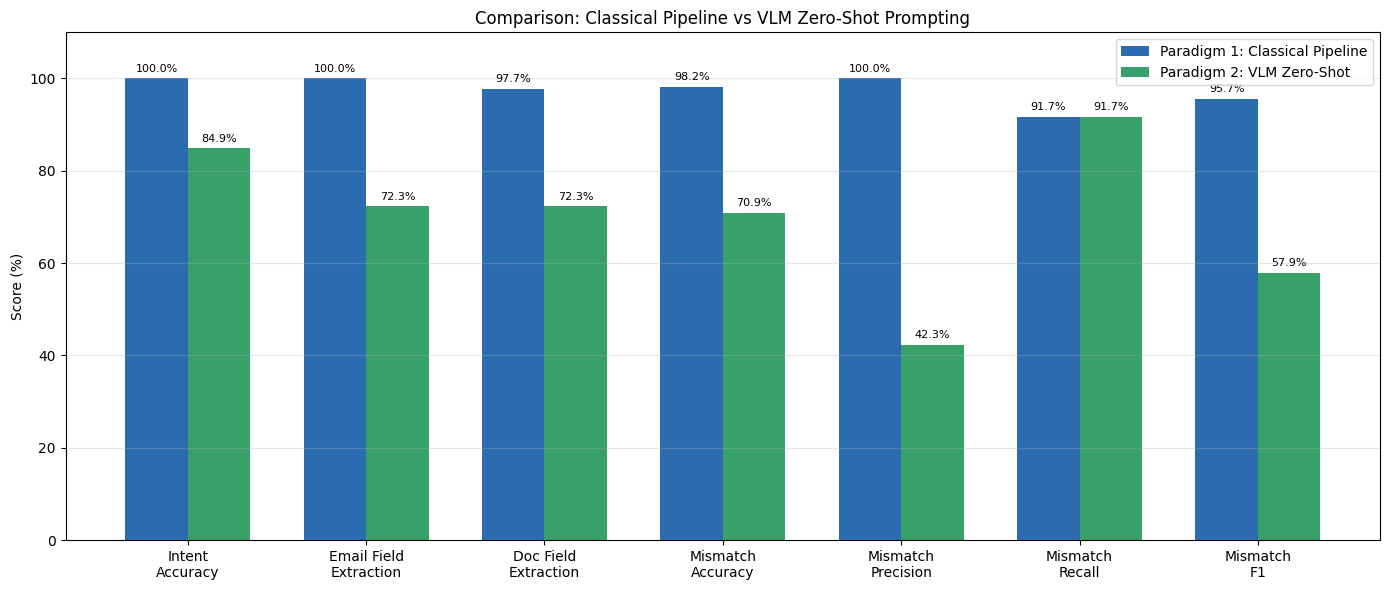

Saved: paradigm_comparison.png


In [ ]:
# 12. Visualization for dissertation
import matplotlib.pyplot as plt
import numpy as np

# Grouped bar chart
metrics = [
    'Intent\nAccuracy', 'Email Field\nExtraction', 'Doc Field\nExtraction',
    'Mismatch\nAccuracy', 'Mismatch\nPrecision', 'Mismatch\nRecall', 'Mismatch\nF1'
]
p1_vals = [P1_INTENT_ACC, P1_EMAIL_FIELD_ACC, P1_DOC_FIELD_ACC,
           P1_MISMATCH_ACC, P1_MISMATCH_PREC, P1_MISMATCH_REC, P1_MISMATCH_F1]
p2_vals = [intent_acc, vlm_email_acc, vlm_doc_acc,
           mm_acc, mm_prec, mm_rec, mm_f1]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, [v*100 for v in p1_vals], width,
               label='Paradigm 1: Classical Pipeline', color='#2b6cb0')
bars2 = ax.bar(x + width/2, [v*100 for v in p2_vals], width,
               label='Paradigm 2: VLM Zero-Shot', color='#38a169')

ax.set_ylabel('Score (%)')
ax.set_title('Comparison: Classical Pipeline vs VLM Zero-Shot Prompting')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 1, f'{h:.1f}%',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 1, f'{h:.1f}%',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('paradigm_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: paradigm_comparison.png')

In [ ]:
# 13. Save all results
all_results = {
    'paradigm_1_classical': {
        'intent_accuracy': P1_INTENT_ACC,
        'intent_f1': P1_INTENT_F1,
        'email_field_accuracy': P1_EMAIL_FIELD_ACC,
        'doc_field_accuracy': P1_DOC_FIELD_ACC,
        'mismatch_accuracy': P1_MISMATCH_ACC,
        'mismatch_precision': P1_MISMATCH_PREC,
        'mismatch_recall': P1_MISMATCH_REC,
        'mismatch_f1': P1_MISMATCH_F1,
    },
    'paradigm_2_vlm': {
        'model': MODEL_ID if 'MODEL_ID' in dir() else 'claude-api',
        'intent_accuracy': float(intent_acc),
        'intent_f1': float(intent_f1),
        'email_field_accuracy': float(vlm_email_acc),
        'doc_field_accuracy': float(vlm_doc_acc),
        'mismatch_accuracy': float(mm_acc),
        'mismatch_precision': float(mm_prec),
        'mismatch_recall': float(mm_rec),
        'mismatch_f1': float(mm_f1),
        'parse_failures': parse_failures,
    },
}

with open('paradigm_comparison_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

# Download
from google.colab import files
files.download('paradigm_comparison_results.json')
files.download('paradigm_comparison.png')
print('\nAll done! Download complete.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All done! Download complete.
